# Week 3 Breakout Slides: Data Visualization

## Using libraries

In engineering disciplines, we seek to minimize inefficient or repetitive effort in the design process. For example, taking an average of a group of numbers is so commonplace, you don't have to write your own code. Therefore, we can use **libraries** to perform common tasks.

In the Python programming language, we use the keyword `import` to import libraries.

In the code segment below, we import `numpy` the workhorse of statistical computing in Python. With `numpy` you can use built-in code, reusable code segments called **functions** to quickly produce a statistical workflow.

Usually in Python we abbreviate `numpy` as `np`, but you could use whatever reference you want (e.g., simply `import numpy` or `import numpy as nump`).

### Import Numpy

In [1]:
import numpy as np

### Build a 1-dimensional group of numbers

In [2]:
first_array = np.array([10, 4, 6, 2, 3, 5])

### Calculate the mean

In [3]:
np.mean(first_array)

np.float64(5.0)

### Build our own mean function


In [4]:
def custom_mean(x):
    return sum(x)/len(x)

In [5]:
custom_mean(first_array)

np.float64(5.0)

### Test our function against a big dataset

In [6]:
import time

#### Generate a large array


In [7]:
large_array = np.random.randint(0, 100, 1000000)

#### Test

In [8]:
start_time = time.perf_counter()

custom_mean(large_array)

end_time = time.perf_counter()

time_custom = end_time - start_time

In [9]:
start_time = time.perf_counter()

np.mean(large_array)

end_time = time.perf_counter()

time_numpy = end_time - start_time

In [10]:
print(time_custom/time_numpy)

61.868727981422424


## Generate distributions

NumPy's `random` module can draw samples from many statistical distributions. The `normal` function takes three key arguments: `loc` sets the center (mean), `scale` sets the spread (standard deviation), and `size` is the number of samples to draw.

In [11]:
norm_dist = np.random.normal(loc=0,
                             scale=2.5,
                             size=10000)

### Mean

In [12]:
np.mean(norm_dist)

np.float64(-0.007764874289800659)

### Standard Deviation

In [13]:
np.std(norm_dist)

np.float64(2.5261153566223125)

### Median

In [14]:
np.median(norm_dist)

np.float64(0.006957539763186942)

### Interquartile Range (IQR)

The IQR is the difference between the 75th and 25th percentiles   a robust measure of spread that ignores extreme values.

In [15]:
np.percentile(norm_dist, 75) - np.percentile(norm_dist, 25)

np.float64(3.4020237841261167)

## Visualize the distribution

### Matplotlib

Matplotlib is a plotting library for Python, and is broadly used for creating scientific and engineering visualizations. Most commonly, we import the module `pyplot` from `matplotlib` as shown in the following code snippet.

In [16]:
import matplotlib.pyplot as plt

(array([  22.,  176.,  912., 2249., 3115., 2384.,  920.,  185.,   32.,
           5.]),
 array([-9.21106494, -7.17722327, -5.1433816 , -3.10953993, -1.07569826,
         0.95814341,  2.99198508,  5.02582675,  7.05966842,  9.09351009,
        11.12735176]),
 <BarContainer object of 10 artists>)

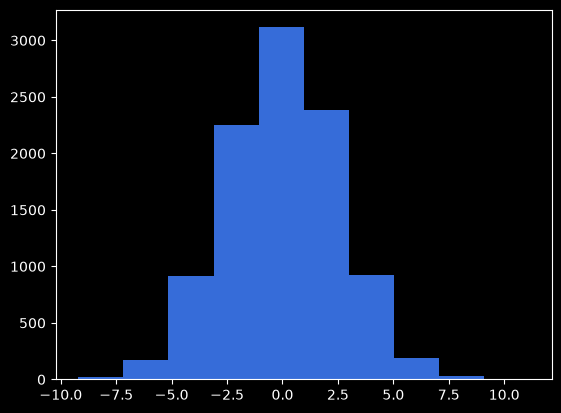

In [17]:
plt.hist(norm_dist)

### Make it look pretty

Basic matplotlib graphics are not great   you need to explore options and the documentation to improve their baseline appearance.

Text(0.5, 1.0, 'Histogram of Normal Distribution')

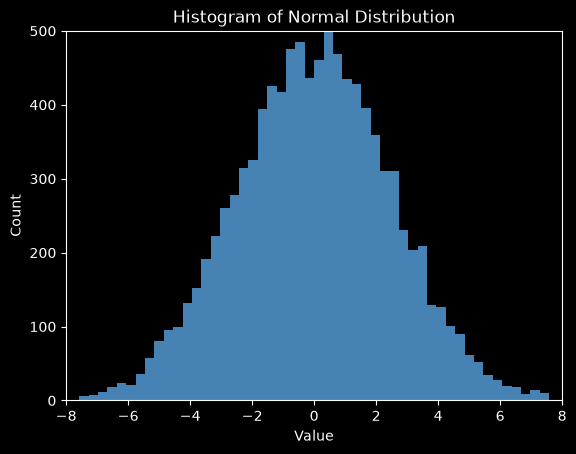

In [18]:
plt.hist(x=norm_dist, # input array
         bins=50,     # number of bins for histogram
         range=(-3 * np.std(norm_dist), # set range of plot to 3 x standard deviation (~99.7% of the data)
                3 * np.std(norm_dist)), # range input is a `tuple` (lower bound, upper bound)
         color='steelblue' # set the color
         )

plt.xlim([-8, 8]) # set x-axis limits
plt.ylim([0, 500]) # set y-axis limits

plt.xlabel('Value')
plt.ylabel('Count')
plt.title('Histogram of Normal Distribution')

### Compare distributions

Generate two normal distributions with different means and standard deviations. Then compare with boxplots.

In [19]:
norm_dist1 = np.random.normal(loc=100, scale=2, size=10000)
norm_dist2 = np.random.normal(loc=95, scale=10, size=10000)

{'whiskers': [<matplotlib.lines.Line2D at 0x12828b380>,
 'caps': [<matplotlib.lines.Line2D at 0x12828b620>,
 'boxes': [<matplotlib.lines.Line2D at 0x12828b230>,
 'medians': [<matplotlib.lines.Line2D at 0x12828b8c0>,
 'fliers': [],
 'means': [<matplotlib.lines.Line2D at 0x12828ba10>,
  <matplotlib.lines.Line2D at 0x1282f8440>]}

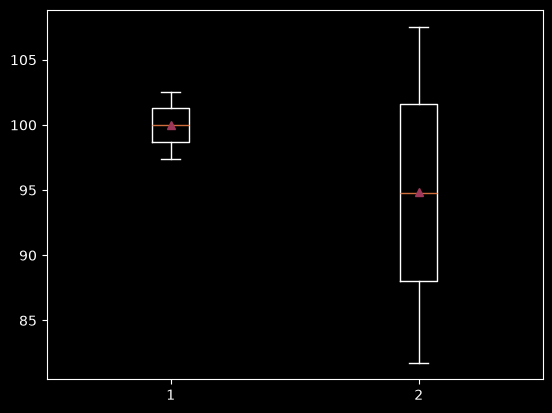

In [20]:

plt.boxplot([norm_dist1, norm_dist2],
            whis=[10, 90], # we set the whiskers to the 10th and 90th percentiles for interpretation
            showfliers=False, # turn off outliers,
            showmeans=True
            )

### Make it look pretty

Raw boxplots lack context. Add axis labels, a title, and meaningful tick labels so the comparison is immediately readable.

Text(0.5, 1.0, 'Comparison of Two Normal Distributions')

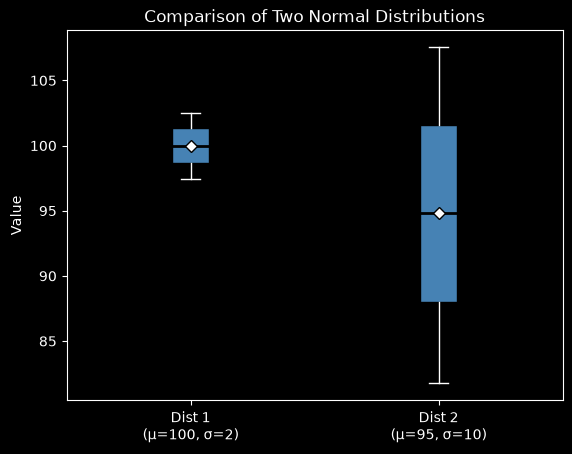

In [21]:
plt.boxplot([norm_dist1, norm_dist2],
            whis=[10, 90],       # whiskers at 10th and 90th percentiles
            showfliers=False,    # hide outliers
            showmeans=True,
            patch_artist=True,   # fill boxes with color
            boxprops=dict(facecolor='steelblue', color='k'),
            medianprops=dict(color='k', linewidth=2),
            meanprops=dict(marker='D', markerfacecolor='white', markeredgecolor='k')
            )

plt.xticks([1, 2], ['Dist 1\n(μ=100, σ=2)', 'Dist 2\n(μ=95, σ=10)'])  # meaningful tick labels
plt.ylabel('Value')
plt.title('Comparison of Two Normal Distributions')

## Statistical Testing

Once we can describe and visualize distributions, the natural next question is: **are these differences meaningful, or just due to chance?** Statistical tests give us a principled, probabilistic answer. We use `scipy.stats`, the scientific computing companion to NumPy.

### Import scipy.stats

In [22]:
from scipy import stats

### One-Sample t-test

Tests whether the mean of a single distribution differs significantly from a known reference value for example, checking whether a manufacturing process is centered on its target specification.

In [23]:
# Is norm_dist1 (μ=100, σ=2) centered on the target value of 100?
t_stat, p_value = stats.ttest_1samp(norm_dist1, popmean=100)
print(f"t-statistic: {t_stat:.4f}")
print(f"p-value:     {p_value:.4f}")

t-statistic: -0.8787
p-value:     0.3796


### Independent Samples t-test

Tests whether two **independent** groups share the same population mean. This is the most common t-test   use it when comparing two separate groups (e.g., two product batches, a control vs. treatment group).

In [24]:
# Compare norm_dist1 (μ=100, σ=2) and norm_dist2 (μ=95, σ=10)
t_stat, p_value = stats.ttest_ind(norm_dist1, norm_dist2)
print(f"t-statistic: {t_stat:.4f}")
print(f"p-value:     {p_value:.4e}")

t-statistic: 50.2790
p-value:     0.0000e+00


### Paired t-test

Tests whether two **paired** measurements differ (e.g., the same subjects measured before and after an intervention). Because each subject serves as their own control, pairing removes between-subject variability and makes the test more sensitive.

In [25]:
# Simulate a before/after intervention on 30 subjects
rng = np.random.default_rng(42)
before = rng.normal(loc=50, scale=5, size=30)
after  = before + rng.normal(loc=2, scale=1, size=30)  # ~2-unit improvement per subject

t_stat, p_value = stats.ttest_rel(before, after)
print(f"t-statistic: {t_stat:.4f}")
print(f"p-value:     {p_value:.4e}")

t-statistic: -14.3871
p-value:     9.8037e-15


### Interpreting Results

The **p-value** is the probability of observing a result at least this extreme if the null hypothesis (no difference) were true. By convention we reject H₀ when p < 0.05. Here we summarize all three tests at once.

In [26]:
alpha = 0.05

results = {
    "One-sample t":  stats.ttest_1samp(norm_dist1, popmean=100).pvalue,
    "Independent t": stats.ttest_ind(norm_dist1, norm_dist2).pvalue,
    "Paired t":      stats.ttest_rel(before, after).pvalue,
}

for test, p in results.items():
    decision = "Reject H₀" if p < alpha else "Fail to reject H₀"
    print(f"{test:<18}  p = {p:.4e}  {decision}")

One-sample t        p = 3.7958e-01  Fail to reject H₀
Independent t       p = 0.0000e+00  Reject H₀
Paired t            p = 9.8037e-15  Reject H₀


### Non-Parametric Tests

t-tests assume the data is roughly normally distributed. When that assumption doesn't hold   for example with skewed data, ordinal ratings, or small samples   use **non-parametric** tests instead. These work by ranking the data rather than assuming any particular shape, making them more robust at the cost of some statistical power.

#### Mann-Whitney U Test

The non-parametric equivalent of the **independent samples t-test**. Tests whether values from one group tend to be systematically larger than the other, without assuming normality.

In [27]:
u_stat, p_value_mw = stats.mannwhitneyu(norm_dist1, norm_dist2, alternative='two-sided')
print(f"U-statistic: {u_stat:.0f}")
print(f"p-value:     {p_value_mw:.4e}")

U-statistic: 69051158
p-value:     0.0000e+00


#### Wilcoxon Signed-Rank Test

The non-parametric equivalent of the **paired t-test**. It ranks the absolute differences between paired observations and tests whether those differences are symmetric around zero.

In [28]:
w_stat, p_value_w = stats.wilcoxon(before, after)
print(f"W-statistic: {w_stat:.0f}")
print(f"p-value:     {p_value_w:.4e}")

W-statistic: 0
p-value:     1.8626e-09


#### Kruskal-Wallis Test

Extends Mann-Whitney to **three or more independent groups**   the non-parametric equivalent of a one-way ANOVA. A significant result tells you at least one group differs; follow-up pairwise tests (e.g., Dunn's test) identify which ones.

In [29]:
norm_dist3 = np.random.normal(loc=98, scale=5, size=10000)

h_stat, p_value_kw = stats.kruskal(norm_dist1, norm_dist2, norm_dist3)
print(f"H-statistic: {h_stat:.4f}")
print(f"p-value:     {p_value_kw:.4e}")

H-statistic: 2719.6334
p-value:     0.0000e+00
